# LLM Fine-Tuning'e Giriş: Kavramdan Uygulamaya

Bu notebook, **büyük dil modellerinin (LLM) fine-tuning (ince ayar)** sürecine sıfırdan giriş yapmak isteyenler için hazırlanmıştır.

## Bu notebook'ta neler var?

1. Fine-tuning'in ne olduğu ve neden gerekli olduğu (kavramsal anlatım)
2. Fine-tuning türleri: Full Fine-Tuning, LoRA, QLoRA, diğer PEFT yöntemleri
3. Uçtan uca pratik bir örnek: küçük bir dil modelini (GPT-2) LoRA ile fine-tune etme
4. Her kod satırının ne işe yaradığının ayrıntılı açıklaması
5. Eğitim sonrası değerlendirme, model kaydetme ve yükleme
6. İleri seviye konulara ve kaynaklara yönlendirme

## Ön koşullar

- Temel Python bilgisi
- Makine öğrenmesi / sinir ağları hakkında genel bir fikir (zorunlu değil ama faydalı)
- Bu notebook'u çalıştırmak için internet bağlantısı (model ve veri indirmek için) ve tercihen bir GPU

> **Not:** Bu notebook eğitim amaçlıdır ve küçük bir model (`distilgpt2`) ile çalışır, böylece CPU üzerinde de (yavaş da olsa) denenebilir. Gerçek projelerde daha büyük modeller (Llama, Mistral, Gemma vb.) ve GPU/QLoRA kullanmanız gerekecektir; bu notebook'ta bu konulara da kavramsal olarak değiniyoruz.


## 1. Fine-Tuning Nedir, Neden Gerekir?

### 1.1 Pretraining ile Fine-tuning Farkı

Bir LLM'in hayatı genellikle iki aşamadan geçer:

- **Pretraining (ön eğitim):** Model, internetten toplanmış devasa miktarda metin üzerinde "bir sonraki kelimeyi (token'ı) tahmin et" görevi ile eğitilir. Bu aşama aylarca sürebilir, milyonlarca dolar maliyetli olabilir ve modele genel dil bilgisi, dünya bilgisi ve akıl yürütme becerisi kazandırır. Çıktı: GPT, Llama, Mistral gibi **temel (base) modeller**.
- **Fine-tuning (ince ayar):** Pretrained modelin ağırlıkları başlangıç noktası olarak alınır ve model, **daha küçük, hedefe özel bir veri seti** üzerinde ek eğitime tabi tutulur. Amaç modele yeni bir davranış, stil, format veya alan bilgisi (domain knowledge) öğretmektir.

Kısaca: *Pretraining modele "dili nasıl konuşacağını" öğretir, fine-tuning ise "bizim istediğimiz şekilde nasıl konuşacağını" öğretir.*

### 1.2 Fine-tuning ne zaman gerekir?

Fine-tuning her problemin çözümü değildir. Aşağıdaki karar tablosunu göz önünde bulundurun:

| Senaryo | Önerilen Yaklaşım |
|---|---|
| Modelin bilmediği güncel/özel bilgiye erişmesi gerekiyor | **RAG** (Retrieval-Augmented Generation) |
| Modelin belirli bir formatta, tonda veya stilde yanıt vermesi gerekiyor | **Fine-tuning** (genellikle birkaç yüz-bin örnek yeterli) |
| Tek seferlik, basit bir görev; veri seti yok | **Prompt engineering** (few-shot prompting) |
| Model belirli bir alanda (tıp, hukuk, finans) uzmanlaşmalı, jargonu öğrenmeli | **Fine-tuning** (domain adaptation) |
| Model insan tercihlerine göre hizalanmalı (yardımseverlik, güvenlik) | **RLHF / DPO** (fine-tuning'in özel bir türü) |
| Çok az veri var (<50 örnek) | Önce prompt engineering deneyin, fine-tuning'e geçmeden |

### 1.3 Fine-tuning'in maliyeti ve riskleri

- **Catastrophic forgetting (felaket unutması):** Model çok agresif fine-tune edilirse pretraining'de öğrendiği genel becerileri unutabilir.
- **Overfitting:** Veri seti küçükse model ezberleyebilir, genelleme yeteneği düşer.
- **Hesaplama maliyeti:** Full fine-tuning, modelin TÜM parametrelerini güncellediği için çok fazla GPU belleği gerektirir (örn. 7B parametreli bir model için onlarca GB VRAM). Bu yüzden **PEFT (Parameter-Efficient Fine-Tuning)** yöntemleri geliştirilmiştir — bu notebook'ta LoRA'yı kullanacağız.


## 2. Fine-Tuning Türleri

### 2.1 Full Fine-Tuning
Modelin **tüm parametreleri** güncellenir. En yüksek performans potansiyeline sahiptir ama:
- Çok fazla GPU belleği gerektirir (model + optimizer state + gradyanlar)
- Her görev için modelin tam bir kopyasını saklamanız gerekir (depolama maliyeti)

### 2.2 PEFT (Parameter-Efficient Fine-Tuning)
Modelin parametrelerinin **çok küçük bir kısmını** (genellikle %1'in altı) eğiterek, geri kalanını dondurur (freeze). Böylece bellek ve depolama maliyeti dramatik şekilde düşer.

En popüler PEFT yöntemi **LoRA (Low-Rank Adaptation)**'dır:

- Orijinal ağırlık matrisi `W` (boyut: d x k) dondurulur, değiştirilmez.
- Bunun yanına, çok daha küçük iki matris eklenir: `A` (d x r) ve `B` (r x k), burada `r` (rank) çok küçük bir sayıdır (örn. 4, 8, 16, 32).
- Eğitim sırasında sadece `A` ve `B` güncellenir. Çıkış şu şekilde hesaplanır:

```
h = W·x + (B·A)·x · (alpha / r)
```

- `r` ne kadar küçükse, eğitilecek parametre sayısı o kadar azalır (ama modelin kapasitesi de sınırlanır).
- `alpha`, LoRA çıkışının ölçeklendirme katsayısıdır; genellikle `r`'nin 1-2 katı seçilir.

**QLoRA**, LoRA'nın bir adım ötesidir: temel model **4-bit'e kuantize edilmiş (quantized)** halde belleğe yüklenir, sadece LoRA katmanları normal hassasiyette (fp16/bf16) eğitilir. Bu sayede 7B-70B parametreli modeller bile tek bir tüketici GPU'sunda (örn. 24GB VRAM) fine-tune edilebilir.

Diğer PEFT yöntemleri (kısaca):
- **Prefix-tuning / Prompt-tuning:** Modelin girişine eğitilebilir "sanal token'lar" eklenir, modelin kendisi değişmez.
- **Adapter katmanları:** Transformer bloklarının arasına küçük, eğitilebilir ek katmanlar (adapters) eklenir.

### 2.3 Veri formatına göre fine-tuning türleri
- **Instruction tuning:** Model "talimat → yanıt" formatında örneklerle eğitilir (örn. Alpaca, FLAN formatı). Bu notebook'ta bunu yapacağız.
- **Domain adaptation:** Model, belirli bir alandaki düz metinler üzerinde devam ettirilen pretraining'e (continued pretraining) tabi tutulur.
- **RLHF / DPO:** Model, insan tercih verileriyle (hangi yanıt daha iyi?) hizalanır. Bu, instruction tuning'den sonraki bir adımdır ve bu notebook'un kapsamı dışındadır.

Bu notebook'ta, küçük bir GPT-2 tabanlı modeli **LoRA ile instruction tuning** yaparak fine-tune edeceğiz.


## 3. Ortam Kurulumu

Aşağıdaki hücre, ihtiyacımız olan kütüphaneleri kurar. Her kütüphanenin görevi şu şekildedir:

- `transformers`: Hugging Face'in model/tokenizer kütüphanesi (GPT-2, Llama, Mistral vb. tüm modeller burada).
- `datasets`: Veri setlerini kolayca yükleme, işleme ve tokenize etme için.
- `peft`: LoRA, prefix-tuning gibi parameter-efficient fine-tuning yöntemlerini uygulamak için (Hugging Face'in PEFT kütüphanesi).
- `accelerate`: Eğitimi CPU/GPU/multi-GPU üzerinde sorunsuzca dağıtmak için (Trainer arka planda bunu kullanır).
- `torch`: PyTorch — modelin ve eğitim döngüsünün çalıştığı temel derin öğrenme kütüphanesi.
- `bitsandbytes`: 4-bit/8-bit kuantizasyon (QLoRA için gereklidir; GPU gerektirir, CPU-only ortamlarda atlanabilir).


In [ ]:
# -q (quiet) bayrağı, kurulum loglarını kısaltır.
# Bu hücreyi yalnızca bir kez çalıştırmanız yeterlidir.
!pip install -q transformers datasets peft accelerate --upgrade
# NOT: bitsandbytes paketi sadece CUDA destekli bir GPU varsa kurulmalıdır (QLoRA örneği için).
# CPU-only bir ortamdaysanız aşağıdaki satırı atlayabilirsiniz.
!pip install -q bitsandbytes --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 7.6 MB/s eta 0:00:00


## 4. Kütüphaneleri İçe Aktarma

Aşağıda kullanacağımız her import'un ne için olduğunu satır satır açıklıyoruz.


In [ ]:
import torch
# torch: PyTorch'un kendisi. Tensörler, GPU/CPU yönetimi ve otomatik türev (autograd) bu kütüphaneden gelir.

import numpy as np
# numpy: Sayısal işlemler ve rastgelelik (seed) ayarları için.

import random
# random: Python'un yerleşik rastgelelik modülü; seed sabitlemek için kullanacağız.

from datasets import Dataset
# datasets.Dataset: Hugging Face'in veri seti sınıfı. Listeden/sözlükten kolayca veri seti oluşturmamızı sağlar
# ve map() fonksiyonu ile toplu (batched) tokenization yapmamıza imkan verir.

from transformers import (
    AutoTokenizer,        # Model adına göre doğru tokenizer'ı otomatik olarak yükler.
    AutoModelForCausalLM, # Model adına göre "causal language modeling" (sıradaki token'ı tahmin etme) mimarisini yükler.
    TrainingArguments,    # Eğitimle ilgili tüm hiperparametreleri (epoch, batch size, learning rate vb.) tutan sınıf.
    Trainer,              # Eğitim döngüsünü (forward, backward, optimizer step, loglama, checkpoint kaydetme) yöneten yüksek seviyeli sınıf.
    DataCollatorForLanguageModeling,  # Bir batch'teki örnekleri aynı uzunluğa getirip (padding) modele uygun formatta birleştiren yardımcı sınıf.
)

from peft import (
    LoraConfig,         # LoRA'nın hiperparametrelerini (r, alpha, hedef katmanlar vb.) tanımlayan konfigürasyon sınıfı.
    get_peft_model,      # Normal bir Hugging Face modelini alıp, üzerine LoRA katmanları ekleyen ("sarmalayan") fonksiyon.
    TaskType,            # PEFT'e bu modelin hangi görev için kullanılacağını bildiren enum (örn. CAUSAL_LM).
    PeftModel,           # Daha sonra kaydedilmiş bir LoRA adaptörünü, temel modelin üzerine tekrar yüklemek için kullanılan sınıf.
)

import matplotlib.pyplot as plt
# matplotlib: Eğitim sırasında kaydedilen loss değerlerini grafikle görselleştirmek için.


## 5. Tekrar Üretilebilirlik (Seed) ve Cihaz Ayarları

Aynı kodu her çalıştırdığımızda benzer sonuçlar almak için rastgelelik kaynaklarını sabitliyoruz. Ayrıca kodun GPU mu yoksa CPU üzerinde mi çalışacağını otomatik olarak belirliyoruz.


In [ ]:
SEED = 42
# SEED: Sabit bir sayı seçiyoruz. Aynı seed, aynı rastgele sayı dizisini üretir -> tekrar üretilebilirlik sağlar.

random.seed(SEED)        # Python'un random modülünün rastgeleliğini sabitle.
np.random.seed(SEED)     # NumPy'ın rastgeleliğini sabitle.
torch.manual_seed(SEED)  # PyTorch CPU işlemlerinin rastgeleliğini sabitle.
torch.cuda.manual_seed_all(SEED)  # Eğer GPU varsa, tüm GPU'lardaki rastgeleliği de sabitle.

device = "cuda" if torch.cuda.is_available() else "cpu"
# torch.cuda.is_available(): Sistemde CUDA destekli bir GPU olup olmadığını kontrol eder.
# Varsa "cuda" (GPU), yoksa "cpu" stringini device değişkenine atarız.

print(f"Kullanılacak cihaz: {device}")
# Hangi cihazda çalıştığımızı ekrana yazdırıyoruz; CPU'da eğitim çok daha yavaş olacaktır.


Kullanılacak cihaz: cpu


## 6. Veri Setini Hazırlama

Instruction tuning için veri, genellikle **(talimat, [opsiyonel girdi], beklenen çıktı)** üçlüsü şeklinde olur. Biz de Alpaca tarzı basit bir format kullanacağız:

```
### Talimat:
{instruction}

### Yanıt:
{output}
```

Gerçek bir projede bu veri seti binlerce/milyonlarca örnek içerir ve genellikle Hugging Face Hub'dan (`datasets.load_dataset(...)`) indirilir. Burada, notebook'un hızlı çalışması ve mantığın anlaşılması için **küçük, elle yazılmış örnek bir veri seti** kullanıyoruz. Kendi projenizde bu listeyi kendi verinizle değiştirmeniz yeterli olacaktır.


In [ ]:
# Küçük, örnek bir instruction-tuning veri seti.
# Her örnek bir sözlük (dict): "instruction" (talimat) ve "output" (beklenen yanıt) anahtarlarını içerir.
# Gerçek projede bu listeyi CSV/JSON dosyasından okuyabilir veya Hugging Face Hub'dan indirebilirsiniz.
raw_examples = [
    {"instruction": "Türkiye'nin başkenti neresidir?", "output": "Türkiye'nin başkenti Ankara'dır."},
    {"instruction": "Fotosentezi tek cümleyle açıkla.", "output": "Fotosentez, bitkilerin güneş ışığını kullanarak karbondioksit ve sudan organik madde ve oksijen ürettiği süreçtir."},
    {"instruction": "Bir bilgisayarın CPU'su ne işe yarar?", "output": "CPU (merkezi işlem birimi), bilgisayardaki komutları işleyip hesaplamaları gerçekleştiren ana donanım birimidir."},
    {"instruction": "Python'da bir liste nasıl tersine çevrilir?", "output": "Bir Python listesini tersine çevirmek için `liste.reverse()` metodunu ya da `liste[::-1]` dilimleme (slicing) ifadesini kullanabilirsiniz."},
    {"instruction": "Makine öğrenmesinde overfitting nedir?", "output": "Overfitting, bir modelin eğitim verisini ezberleyip yeni, görmediği verilerde iyi genelleme yapamaması durumudur."},
    {"instruction": "Bir e-posta için kibar bir kapanış cümlesi yaz.", "output": "İlginiz için şimdiden teşekkür ederim, iyi çalışmalar dilerim."},
    {"instruction": "İklim değişikliğinin bir sonucunu yaz.", "output": "İklim değişikliği, deniz seviyelerinin yükselmesine ve aşırı hava olaylarının sıklaşmasına neden olmaktadır."},
    {"instruction": "Bir döngü (loop) ne işe yarar?", "output": "Bir döngü, belirli bir kod bloğunu, bir koşul sağlandığı sürece veya belirli bir sayıda tekrar tekrar çalıştırmak için kullanılır."},
]
# NOT: Gerçek bir fine-tuning için en az birkaç yüz, idealde birkaç bin kaliteli örnek önerilir.
# Bu küçük liste tamamen kodun NASIL ÇALIŞTIĞINI göstermek içindir.

print(f"Toplam örnek sayısı: {len(raw_examples)}")
# Veri setimizin boyutunu kontrol ediyoruz.


Toplam örnek sayısı: 8


In [ ]:
def format_example(example):
    # Bu fonksiyon, her bir (instruction, output) çiftini, modele tek bir metin (prompt) olarak verilecek
    # standart bir şablona dönüştürür. Bu şablona "prompt template" denir.
    text = (
        f"### Talimat:\n{example['instruction']}\n\n"   # Talimat (kullanıcının sorusu/isteği) başlığı altında yazılır.
        f"### Yanıt:\n{example['output']}"                # Modelin üretmesi gereken yanıt, "### Yanıt:" başlığı altında yazılır.
    )
    return {"text": text}
    # Fonksiyon, "text" anahtarına sahip bir sözlük döndürür; bu, Dataset.map() ile uyumlu çalışmasını sağlar.

dataset = Dataset.from_list(raw_examples)
# Dataset.from_list: Python listesindeki sözlükleri alıp bir Hugging Face Dataset nesnesine çevirir.
# Bu nesne, .map(), .shuffle(), .train_test_split() gibi kullanışlı metotlar sunar.

dataset = dataset.map(format_example)
# .map(): Veri setindeki HER örneğe format_example fonksiyonunu uygular ve sonuçları yeni sütun(lar) olarak ekler.
# Sonuçta her örnekte artık bir de "text" alanı bulunacak (orijinal "instruction" ve "output" alanları da kalır).

print(dataset[0]["text"])
# İlk örneğin nihai metin halini ekrana yazdırarak şablonun doğru çalıştığını doğruluyoruz.


Map:   0%|          | 0/8 [00:00<?, ? examples/s]

### Talimat:
Türkiye'nin başkenti neresidir?

### Yanıt:
Türkiye'nin başkenti Ankara'dır.


## 7. Temel Model ve Tokenizer'ı Yükleme

Bu örnekte `distilgpt2` modelini kullanıyoruz: GPT-2'nin damıtılmış (distilled), daha küçük ve hızlı bir versiyonu. Bu sayede notebook CPU üzerinde de makul bir sürede çalışabilir. Gerçek bir projede bunun yerine daha güçlü, daha güncel bir temel model (örn. `meta-llama/Llama-3.1-8B`, `mistralai/Mistral-7B-v0.1`) kullanırsınız; kod mantığı büyük ölçüde aynı kalır.


In [ ]:
MODEL_NAME = "distilgpt2"
# MODEL_NAME: Hugging Face Hub'daki model kimliği. "distilgpt2", GPT-2'nin küçültülmüş halidir (~82M parametre).

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# AutoTokenizer.from_pretrained: Belirtilen model için doğru tokenizer'ı (kelime/alt-kelime bölme mantığını) indirir ve yükler.
# Tokenizer, ham metni modelin anlayabileceği sayısal token ID'lerine çevirir.

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
# GPT-2 ailesi modellerde varsayılan olarak bir "pad_token" (doldurma token'ı) tanımlı değildir.
# Batch içindeki metinleri aynı uzunluğa getirmek (padding) için bir pad_token gereklidir.
# Burada, var olan "eos_token" (end-of-sequence, dizinin sonu token'ı) pad_token olarak yeniden kullanılır.

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
# AutoModelForCausalLM.from_pretrained: Önceden eğitilmiş (pretrained) ağırlıklarla modeli indirir ve belleğe yükler.
# "CausalLM" = modelin görevi, önceki token'lara bakarak SIRADAKİ token'ı tahmin etmektir (GPT tarzı modellerin temel görevi).

model.to(device)
# Modeli daha önce belirlediğimiz cihaza (GPU varsa "cuda", yoksa "cpu") taşıyoruz.

print(f"Model parametre sayısı: {model.num_parameters():,}")
# Modelin toplam (henüz fine-tune edilmemiş) parametre sayısını insan tarafından okunabilir formatta yazdırıyoruz.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model parametre sayısı: 81,912,576


## 8. Veriyi Tokenize Etme

Modelin metni anlayabilmesi için önce sayısal token ID'lerine dönüştürülmesi (tokenization) gerekir. Aşağıdaki fonksiyon her örneği tokenize eder ve `labels` (etiketler) alanını da `input_ids` ile aynı yaparak, modelin "bir önceki token'lardan sonraki token'ı tahmin et" görevini (causal language modeling) öğrenmesini sağlar.


In [ ]:
MAX_LENGTH = 128
# MAX_LENGTH: Her örneğin maksimum token uzunluğu. Bundan uzun metinler kesilir (truncation),
# kısa metinler ise pad_token ile bu uzunluğa tamamlanır (padding).
# Gerçek projelerde bu değer veri setinizin tipik uzunluğuna göre (örn. 512, 1024, 2048) ayarlanır.

def tokenize_function(examples):
    # examples: dataset.map(batched=True) kullanıldığı için, burada TEK bir örnek değil,
    # bir LISTE halinde birden çok örneğin "text" alanı gelir (örn. examples["text"] bir string listesidir).
    tokenized = tokenizer(
        examples["text"],          # Tokenize edilecek ham metin listesi.
        truncation=True,           # MAX_LENGTH'ten uzun metinleri kes.
        max_length=MAX_LENGTH,     # Maksimum token uzunluğu.
        padding="max_length",      # Tüm örnekleri MAX_LENGTH'e tamamla (sabit uzunluk -> batching için kolaylık).
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    # "labels": Modelin tahmin etmesi GEREKEN doğru token ID'leri.
    # Causal language modeling'de etiketler, girdinin (input_ids) bir kopyasıdır;
    # Trainer/model içeride otomatik olarak "bir token kaydırma" (shift) işlemini yapar,
    # böylece model t. pozisyondaki token'dan, t+1. pozisyondaki token'ı tahmin etmeyi öğrenir.
    return tokenized

tokenized_dataset = dataset.map(
    tokenize_function,    # Az önce tanımladığımız tokenize fonksiyonu.
    batched=True,         # Performans için örnekleri tek tek değil, toplu (batch) halinde işler.
    remove_columns=dataset.column_names,
    # Artık ihtiyacımız olmayan orijinal sütunları (instruction, output, text) kaldırıyoruz;
    # geriye sadece model için gereken input_ids, attention_mask ve labels kalır.
)

print(tokenized_dataset)
# Tokenize edilmiş veri setinin yapısını (sütunlar, örnek sayısı) ekrana yazdırarak kontrol ediyoruz.


Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 8
})


## 9. LoRA Konfigürasyonunu Tanımlama

Şimdi modelimize LoRA katmanlarını ekleyeceğiz. `LoraConfig` parametrelerini tek tek açıklayalım:

| Parametre | Anlamı |
|---|---|
| `r` | LoRA matrislerinin rank'i (boyutu). Küçük değer (4-16) az parametre/hızlı eğitim; büyük değer (32-64) daha fazla kapasite/daha çok bellek. |
| `lora_alpha` | LoRA çıkışının ölçeklendirme katsayısı. Genellikle `r`'nin 1-2 katı seçilir (örn. r=8 ise alpha=16). |
| `target_modules` | LoRA'nın hangi katmanlara uygulanacağı (genellikle attention'daki query/key/value/output projeksiyon katmanları). |
| `lora_dropout` | LoRA katmanlarına uygulanan dropout oranı; aşırı öğrenmeyi (overfitting) azaltmaya yardımcı olur. |
| `bias` | Bias terimlerinin eğitilip eğitilmeyeceği ("none", "all", "lora_only"). |
| `task_type` | PEFT'e bu modelin görev tipini bildirir (burada `CAUSAL_LM`). |


In [12]:
pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 14.3 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [13]:
lora_config = LoraConfig(
    r=8,                        # Rank: LoRA matrislerinin iç boyutu. Düşük rank, az parametre demektir.
    lora_alpha=16,               # Ölçeklendirme katsayısı (genelde r'nin 2 katı tercih edilir).
    target_modules=["c_attn"],   # GPT-2 mimarisinde, query/key/value projeksiyonlarını içeren birleşik katmanın adı.
                                  # Farklı mimarilerde (Llama, Mistral) bu isim değişir (örn. ["q_proj", "v_proj"]).
    lora_dropout=0.05,            # LoRA katmanlarına %5 dropout uygulanır -> aşırı öğrenmeye karşı küçük bir önlem.
    bias="none",                  # Bias terimleri eğitilmeyecek (en yaygın ve hafif tercih).
    task_type=TaskType.CAUSAL_LM, # Bu, bir "causal language modeling" (GPT tarzı, sıradaki token'ı tahmin etme) görevidir.
)

model = get_peft_model(model, lora_config)
# get_peft_model: Verilen temel modeli (distilgpt2) alır, target_modules içinde belirtilen katmanların
# yanına LoRA matrislerini (A ve B) ekler ve orijinal ağırlıkları DONDURUR (requires_grad=False).
# Sadece yeni eklenen LoRA matrisleri eğitilebilir (requires_grad=True) hale gelir.

model.print_trainable_parameters()
# PEFT'in sunduğu bu metot, kaç parametrenin eğitilebilir olduğunu ve bunun toplam parametrelere oranını gösterir.
# Beklenen çıktı, eğitilebilir parametre oranının ÇOK küçük (genellikle %1'in altı) olduğunu gösterecektir.

trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.1797


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 10. Eğitim Argümanlarını (TrainingArguments) Tanımlama

`TrainingArguments`, eğitim sürecinin nasıl ilerleyeceğini belirleyen tüm hiperparametreleri tutar.


In [14]:
training_args = TrainingArguments(
    output_dir="./lora-distilgpt2-output",
    # Eğitim sırasında oluşturulan checkpoint'lerin ve logların kaydedileceği klasör.

    num_train_epochs=3,
    # Epoch: Modelin tüm veri setini KAÇ KEZ baştan sona göreceği. Küçük veri setlerinde epoch sayısı
    # genellikle daha yüksek (3-10), büyük veri setlerinde daha düşük (1-3) tutulur.

    per_device_train_batch_size=2,
    # Her bir adımda (GPU/CPU başına) aynı anda işlenecek örnek sayısı. Bellek kısıtlıysa bu değer düşük tutulur.

    gradient_accumulation_steps=4,
    # Gradyan biriktirme: Bellek yetmediğinde, küçük batch'lerin gradyanlarını N adım boyunca topla,
    # sonra TEK seferde optimizer adımı at. Etkili batch boyutu = batch_size * accumulation_steps = 2*4 = 8.

    learning_rate=2e-4,
    # Öğrenme oranı: Her adımda ağırlıkların ne kadar güncelleneceğini belirler.
    # LoRA fine-tuning'de full fine-tuning'e göre genellikle daha YÜKSEK bir learning rate (1e-4 - 3e-4) kullanılır,
    # çünkü sadece küçük LoRA matrisleri eğitiliyor.

    logging_steps=2,
    # Her 2 adımda bir, eğitim loss'unu (kaybını) konsola/loglara yazdır.

    save_strategy="epoch",
    # Modeli (LoRA adaptörünü) her epoch sonunda kaydet.

    fp16=torch.cuda.is_available(),
    # fp16 (16-bit kayan nokta, mixed precision): Eğer GPU varsa eğitimi hızlandırmak ve bellek tasarrufu
    # sağlamak için yarım hassasiyetli sayılar kullan. CPU'da fp16 desteklenmediği için bunu kapalı tutuyoruz.

    report_to="none",
    # Eğitim metriklerini herhangi bir dış servise (örn. Weights&Biases) GÖNDERME; sadece yerel logla.
)


## 11. Trainer Oluşturma ve Eğitimi Başlatma

`Trainer`, eğitim döngüsünün (forward pass → loss hesaplama → backward pass → optimizer adımı) tüm karmaşık detaylarını bizim için yönetir.


In [15]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    # DataCollatorForLanguageModeling: Bir batch'teki örnekleri alıp, modele verilecek son tensörleri
    # (input_ids, attention_mask, labels) doğru şekilde hazırlayan/birleştiren yardımcı sınıf.

    mlm=False,
    # mlm=False: "Masked Language Modeling" (BERT tarzı, rastgele token maskeleme) DEĞİL,
    # "Causal Language Modeling" (GPT tarzı, soldan sağa tahmin) yapıyoruz demek.
)

trainer = Trainer(
    model=model,                       # Az önce LoRA katmanları eklenmiş model.
    args=training_args,                 # Tanımladığımız eğitim hiperparametreleri.
    train_dataset=tokenized_dataset,     # Tokenize edilmiş eğitim veri seti.
    data_collator=data_collator,         # Batch'leri hazırlayan collator.
)

trainer.train()
# .train(): Eğitim döngüsünü başlatır. Arka planda her adımda:
#   1) Bir batch veri alınır,
#   2) Model ileri besleme (forward pass) yapar ve loss hesaplanır,
#   3) Geri yayılım (backward pass) ile gradyanlar hesaplanır,
#   4) Optimizer (varsayılan: AdamW), SADECE eğitilebilir (LoRA) parametreleri günceller,
#   5) Belirlenen aralıklarla loss loglanır ve checkpoint kaydedilir.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
2,5.450901


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=3, training_loss=5.456736087799072, metrics={'train_runtime': 99.7876, 'train_samples_per_second': 0.241, 'train_steps_per_second': 0.03, 'total_flos': 786608160768.0, 'train_loss': 5.456736087799072, 'epoch': 3.0})

## 12. Eğitim Sonrası Değerlendirme

### 12.1 Loss Grafiği

Eğitim sırasında kaydedilen loss değerlerini görselleştirerek modelin öğrenip öğrenmediğini (loss'un düşüp düşmediğini) kontrol edebiliriz.


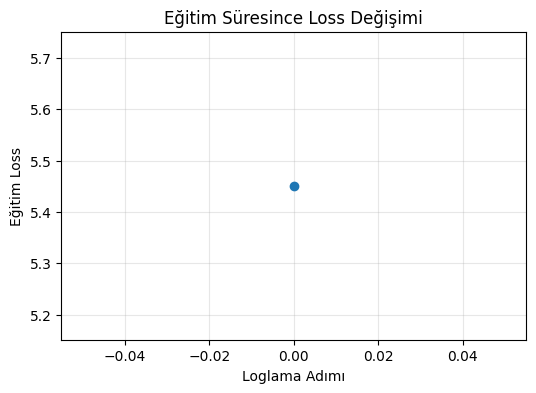

In [16]:
log_history = trainer.state.log_history
# trainer.state.log_history: Eğitim sırasında her loglama adımında kaydedilen metrik sözlüklerinin listesi.

losses = [entry["loss"] for entry in log_history if "loss" in entry]
# Liste içindeki her sözlükten, varsa "loss" anahtarının değerini çekip yeni bir listeye topluyoruz.

plt.figure(figsize=(6, 4))     # 6x4 inç boyutunda yeni bir grafik alanı oluştur.
plt.plot(losses, marker="o")    # Loss değerlerini, her noktada bir daire işaretiyle çiz.
plt.xlabel("Loglama Adımı")     # X ekseni etiketi.
plt.ylabel("Eğitim Loss")        # Y ekseni etiketi.
plt.title("Eğitim Süresince Loss Değişimi")  # Grafik başlığı.
plt.grid(True, alpha=0.3)        # Hafif şeffaflıkta (alpha=0.3) bir ızgara ekle, okunabilirliği artırır.
plt.show()                        # Grafiği ekrana çiz/göster.


### 12.2 Fine-tuning Öncesi/Sonrası Karşılaştırma

Şimdi modele bir talimat verip, fine-tuning sonrası nasıl bir yanıt ürettiğini görelim.


In [17]:
def generate_response(model, instruction, max_new_tokens=40):
    # Bu fonksiyon, verilen bir talimata göre modelin yanıtını üretir.
    prompt = f"### Talimat:\n{instruction}\n\n### Yanıt:\n"
    # Eğitimde kullandığımız İLE AYNI şablonu kullanıyoruz; model bu formata aşina.

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    # Prompt'u tokenize ediyoruz ve PyTorch tensörleri olarak (return_tensors="pt") alıp doğru cihaza taşıyoruz.

    with torch.no_grad():
        # torch.no_grad(): Üretim (inference) sırasında gradyan hesaplamaya gerek yok;
        # bunu kapatmak belleği ve hesaplama süresini önemli ölçüde azaltır.
        output_ids = model.generate(
            **inputs,                     # input_ids ve attention_mask'i fonksiyona aç (unpack) ederek geçiriyoruz.
            max_new_tokens=max_new_tokens,  # Talimattan SONRA en fazla kaç yeni token üretileceği.
            do_sample=True,                  # True: olasılıksal örnekleme yap (daha çeşitli/yaratıcı çıktı).
                                              # False olsaydı: her zaman en olası token seçilirdi (greedy/deterministic).
            temperature=0.7,                  # Olasılık dağılımının "keskinliğini" ayarlar; düşük değer daha tutarlı,
                                                # yüksek değer daha rastgele/yaratıcı çıktı üretir.
            top_p=0.9,                          # Nucleus sampling: kümülatif olasılığı %90'a ulaşan en olası token
                                                  # kümesinden seçim yapar, çok düşük olasılıklı token'ları eler.
            pad_token_id=tokenizer.pad_token_id,  # Padding için kullanılacak token ID'sini modele bildiriyoruz.
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # tokenizer.decode: Üretilen sayısal token ID dizisini geri OKUNABİLİR metne çevirir.
    # skip_special_tokens=True: <eos>, <pad> gibi özel token'ları çıktıdan temizler.

    return generated_text

test_instruction = "Yapay zeka nedir, kısaca açıkla."
print(generate_response(model, test_instruction))
# Fine-tune edilmiş modelin, hiç görmediği yeni bir talimata nasıl yanıt verdiğini gözlemliyoruz.


### Talimat:
Yapay zeka nedir, kısaca açıkla.

### Yanıt:
As we were talking in the morning, we were going to a store on the south side of the city, so we had to make sure that the shop was full. I had to go to the


## 13. LoRA Adaptörünü Kaydetme ve Yeniden Yükleme

LoRA'nın en büyük avantajlarından biri, kaydedilen dosyanın ÇOK küçük olmasıdır (sadece LoRA matrisleri, ~birkaç MB) — tüm modeli (~yüzlerce MB/GB) tekrar kaydetmeye gerek yoktur.


In [18]:
ADAPTER_DIR = "./lora-distilgpt2-adapter"
# Adaptörün kaydedileceği klasör yolu.

model.save_pretrained(ADAPTER_DIR)
# save_pretrained: PEFT modelinin SADECE eğitilen LoRA katmanlarını (adapter_model.bin/safetensors)
# ve konfigürasyonunu (adapter_config.json) diske kaydeder. Temel model ağırlıkları KAYDEDİLMEZ
# (çünkü onlar değişmedi, Hugging Face Hub'dan her zaman tekrar indirilebilirler).

tokenizer.save_pretrained(ADAPTER_DIR)
# Tokenizer'ı da aynı klasöre kaydediyoruz, böylece ileride hem modeli hem tokenizer'ı aynı yerden yükleyebiliriz.

print(f"Adaptör şu klasöre kaydedildi: {ADAPTER_DIR}")


Adaptör şu klasöre kaydedildi: ./lora-distilgpt2-adapter


In [19]:
# --- Kaydedilen adaptörü, SIFIRDAN bir oturumda nasıl yüklersiniz? ---

base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
# 1. Adım: Önce orijinal, fine-tune edilMEMİŞ temel modeli tekrar yüklüyoruz.

fine_tuned_model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
# 2. Adım: PeftModel.from_pretrained, temel modelin üzerine, diskte sakladığımız
# LoRA adaptör ağırlıklarını yükler ve "birleştirir" (runtime'da, A ve B matrislerini W'ye ekleyerek çalışır).

fine_tuned_model.to(device)
# Modeli yine doğru cihaza taşıyoruz.

print("Adaptör başarıyla yüklendi, model kullanıma hazır.")


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Adaptör başarıyla yüklendi, model kullanıma hazır.


## 14. İleri Düzey Konular ve En İyi Pratikler

### 14.1 QLoRA ile büyük modelleri fine-tune etme

Daha büyük bir modeli (örn. 7B parametre) tek bir tüketici GPU'sunda eğitmek için QLoRA kullanılır. Temel fark, modelin 4-bit kuantize edilmiş halde yüklenmesidir:

```python
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                 # Modeli 4-bit hassasiyetle yükle (bellek kullanımını ~4x azaltır).
    bnb_4bit_quant_type="nf4",          # "Normal Float 4" kuantizasyon tipi; LLM ağırlıkları için optimize edilmiştir.
    bnb_4bit_compute_dtype=torch.bfloat16,  # Hesaplamalar (matris çarpımları) bf16 hassasiyetinde yapılır.
    bnb_4bit_use_double_quant=True,      # Kuantizasyon sabitlerini de tekrar kuantize ederek ekstra bellek tasarrufu sağlar.
)

model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-v0.1",
    quantization_config=bnb_config,
    device_map="auto",   # Modelin katmanlarını otomatik olarak mevcut GPU(lar)a/CPU'ya dağıtır.
)
```

Bu noktadan sonraki LoRA/Trainer adımları, bu notebook'takiyle neredeyse aynıdır.

### 14.2 Hiperparametre seçimi için pratik öneriler

- **`r` (LoRA rank):** 8-16 ile başlayın; daha karmaşık görevlerde 32-64'e çıkarabilirsiniz.
- **Learning rate:** LoRA için 1e-4 - 3e-4 aralığı genellikle iyi sonuç verir; full fine-tuning'de bu çok daha düşüktür (1e-5 - 5e-5).
- **Epoch sayısı:** Veri setiniz küçükse (yüzlerce örnek) 3-5 epoch; veri setiniz büyükse (on binlerce örnek) 1-2 epoch genellikle yeterlidir. Validasyon loss'unun yükselmeye başladığı noktada durun (early stopping).
- **Veri kalitesi > veri miktarı:** Az ama temiz, tutarlı formatlı, çeşitli örnekler; çok ama gürültülü veriden daha iyi sonuç verir.

### 14.3 Sıradaki adımlar
- **Değerlendirme metrikleri:** Görevinize uygun metrikler kullanın (ör. üretilen metin görevlerinde ROUGE/BLEU, sınıflandırmada accuracy/F1, ya da insan/LLM tabanlı değerlendirme).
- **DPO / RLHF:** Instruction tuning sonrası, modelin yanıt KALİTESİNİ insan tercihlerine göre daha da iyileştirmek isterseniz `trl` kütüphanesindeki `DPOTrainer` veya `PPOTrainer`'a bakabilirsiniz.
- **Hazır araçlar:** Üretim seviyesinde fine-tuning için `trl`, `axolotl` veya `LLaMA-Factory` gibi üst seviye kütüphaneler, bu notebook'taki adımların çoğunu sizin için otomatikleştirir.

## 15. Kaynaklar

- LoRA makalesi: Hu et al., *"LoRA: Low-Rank Adaptation of Large Language Models"* (2021)
- QLoRA makalesi: Dettmers et al., *"QLoRA: Efficient Finetuning of Quantized LLMs"* (2023)
- Hugging Face PEFT dokümantasyonu: https://huggingface.co/docs/peft
- Hugging Face Transformers dokümantasyonu: https://huggingface.co/docs/transformers
